# Bad models and performance on diff trial types

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *


2025-05-19 14:36:58.083854: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 14:36:58.158284: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-19 14:36:58.187869: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-19 14:36:58.196099: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-19 14:36:58.243888: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

In [4]:
# get all of the bad models and their performances

bad_models, bad_perfs = ld.get_models_by_perf(low_cutoff=0.6, high_cutoff=0.8, 
                                              condn_phrase=condn_phrase, condn_num=condn_num)


Found 28 models with performance between 0.6 and 0.8


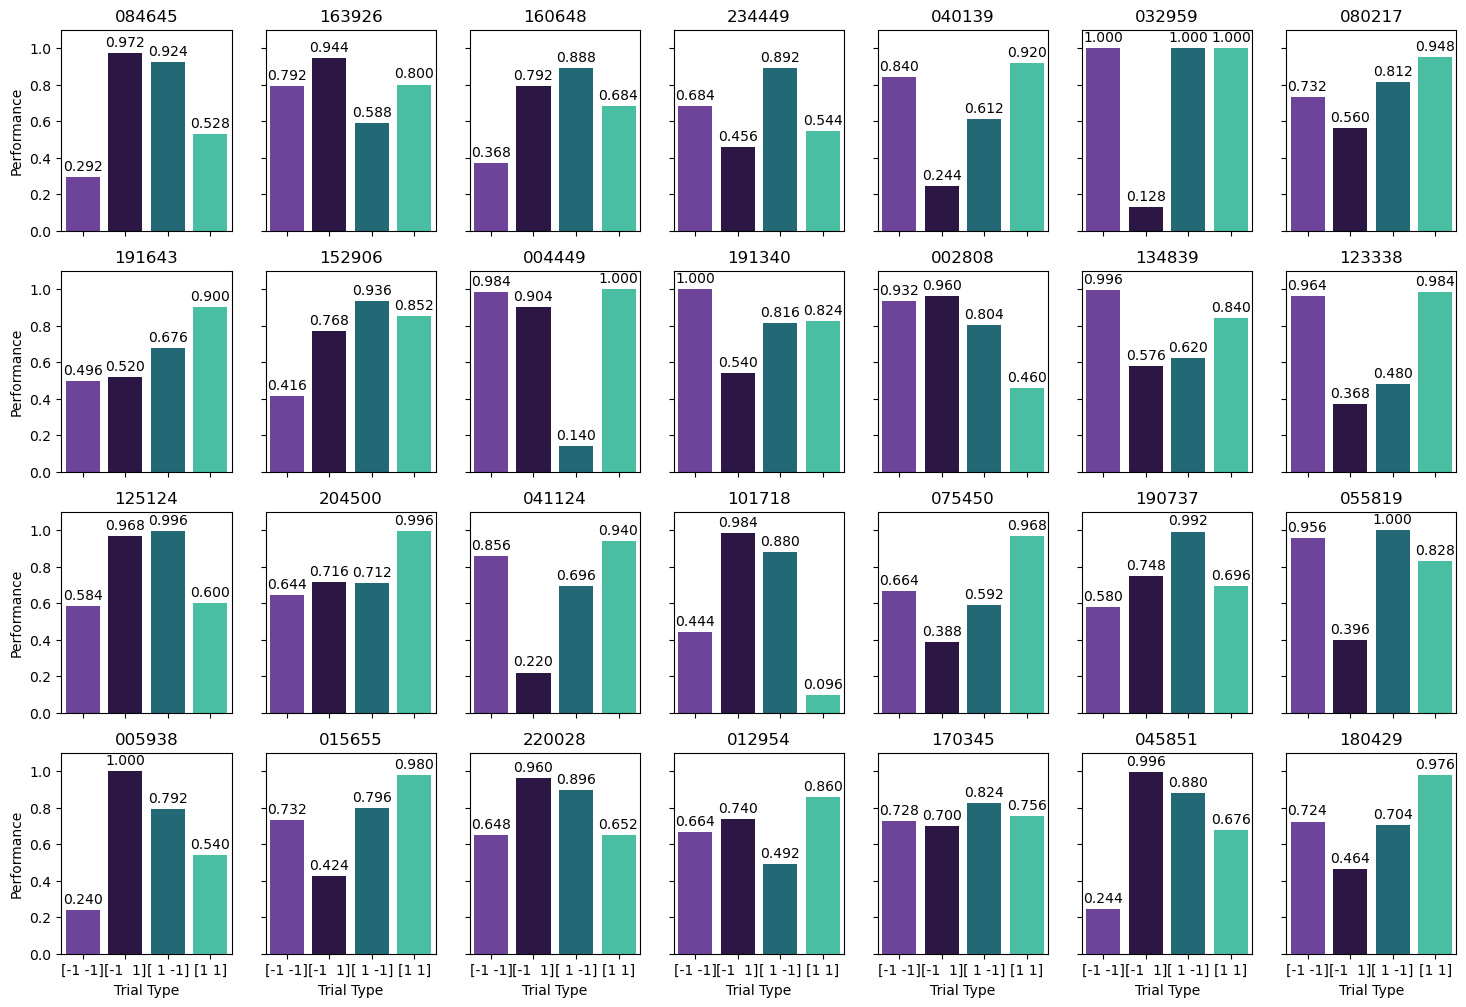

In [5]:
importlib.reload(bhv)

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 7, figsize=(18, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(bad_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 7 != 0:
        axs[i].set_ylabel('')
    if i < 21:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 7 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659']
